In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Load UCI German Credit dataset
dataset = fetch_ucirepo(id=144)
X = dataset.data.features
y = dataset.data.targets

# Combine into one dataframe
df = X.copy()
df['credit_risk'] = y['class'].values

# Recode: 1=good→0, 2=bad→1
df['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['credit_risk'].value_counts())
print(f"\nClass ratio: {df['credit_risk'].mean():.1%} bad credit")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nFeature types:")
print(df.dtypes.value_counts())

Dataset shape: (1000, 21)

Class distribution:
credit_risk
0    700
1    300
Name: count, dtype: int64

Class ratio: 30.0% bad credit

Missing values: 0

Feature types:
str      13
int64     8
Name: count, dtype: int64


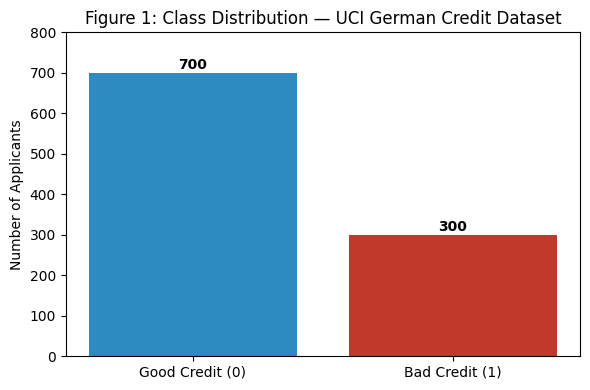

Saved to shap_plots/class_distribution.png


In [7]:
# Class distribution plot
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['credit_risk'].value_counts()
bars = ax.bar(['Good Credit (0)', 'Bad Credit (1)'], 
              counts.values, color=['#2E8BC0', '#C0392B'])
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', fontweight='bold')
ax.set_ylabel('Number of Applicants')
ax.set_title('Figure 1: Class Distribution — UCI German Credit Dataset')
ax.set_ylim(0, 800)
plt.tight_layout()
plt.savefig('../shap_plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to shap_plots/class_distribution.png")

In [8]:
# Identify categorical and numerical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('credit_risk')  # remove target

print(f"Categorical features ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c}: {df[c].nunique()} unique values — {df[c].unique()[:5]}")

print(f"\nNumerical features ({len(num_cols)}):")
for c in num_cols:
    print(f"  {c}: min={df[c].min()}, max={df[c].max()}, mean={df[c].mean():.1f}")

Categorical features (13):
  Attribute1: 4 unique values — <StringArray>
['A11', 'A12', 'A14', 'A13']
Length: 4, dtype: str
  Attribute3: 5 unique values — <StringArray>
['A34', 'A32', 'A33', 'A30', 'A31']
Length: 5, dtype: str
  Attribute4: 10 unique values — <StringArray>
['A43', 'A46', 'A42', 'A40', 'A41']
Length: 5, dtype: str
  Attribute6: 5 unique values — <StringArray>
['A65', 'A61', 'A63', 'A64', 'A62']
Length: 5, dtype: str
  Attribute7: 5 unique values — <StringArray>
['A75', 'A73', 'A74', 'A71', 'A72']
Length: 5, dtype: str
  Attribute9: 4 unique values — <StringArray>
['A93', 'A92', 'A91', 'A94']
Length: 4, dtype: str
  Attribute10: 3 unique values — <StringArray>
['A101', 'A103', 'A102']
Length: 3, dtype: str
  Attribute12: 4 unique values — <StringArray>
['A121', 'A122', 'A124', 'A123']
Length: 4, dtype: str
  Attribute14: 3 unique values — <StringArray>
['A143', 'A141', 'A142']
Length: 3, dtype: str
  Attribute15: 3 unique values — <StringArray>
['A152', 'A153', 'A151']


C:\Users\capsy\AppData\Local\Temp\ipykernel_4792\4101603904.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


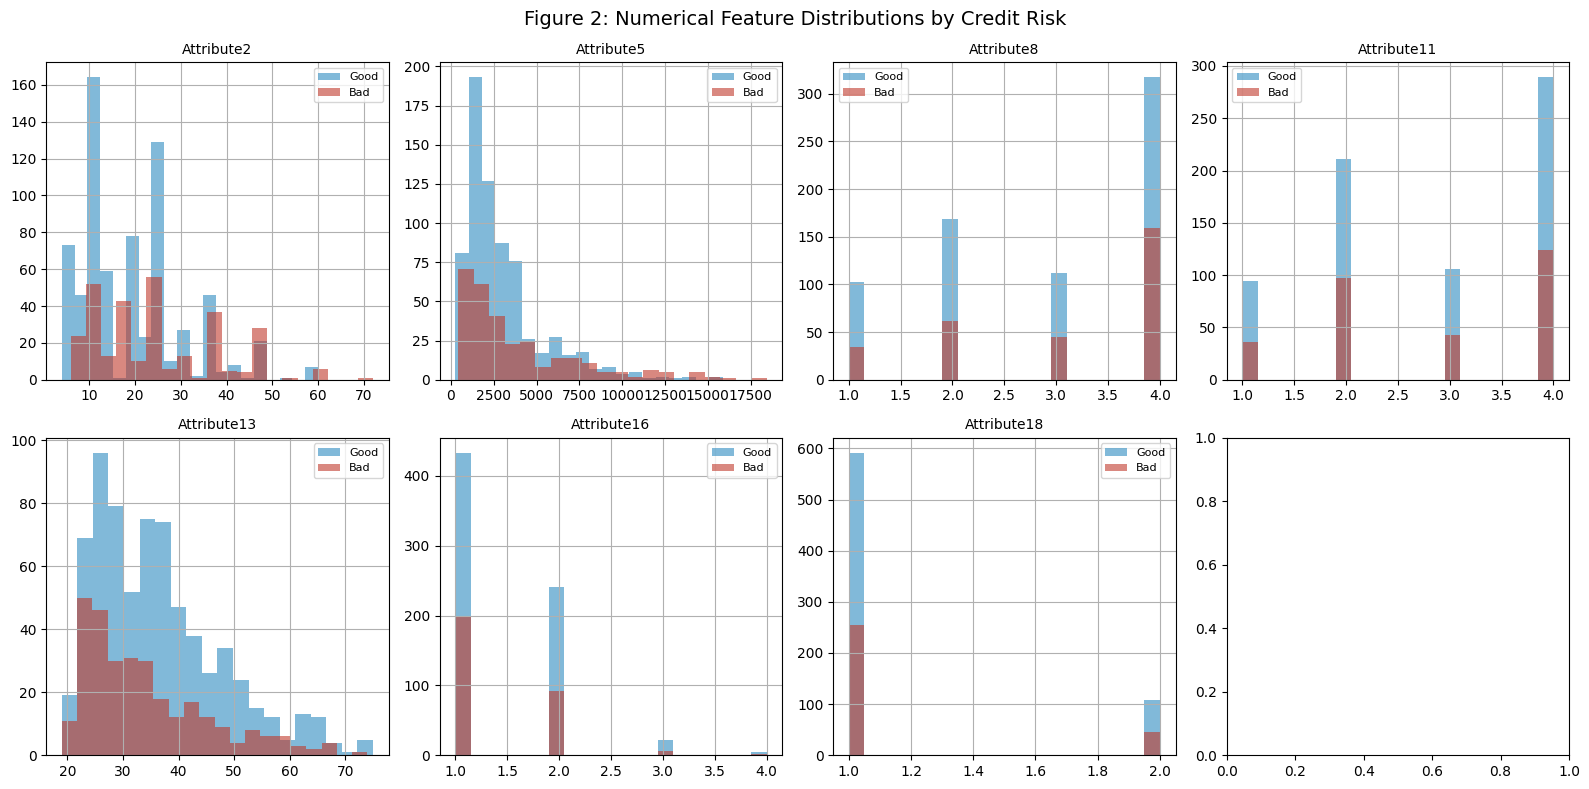

In [9]:
# Numerical feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:8]):
    ax = axes[i]
    df[df['credit_risk']==0][col].hist(ax=ax, alpha=0.6, label='Good', color='#2E8BC0', bins=20)
    df[df['credit_risk']==1][col].hist(ax=ax, alpha=0.6, label='Bad', color='#C0392B', bins=20)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Figure 2: Numerical Feature Distributions by Credit Risk', fontsize=14)
plt.tight_layout()
plt.savefig('../shap_plots/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

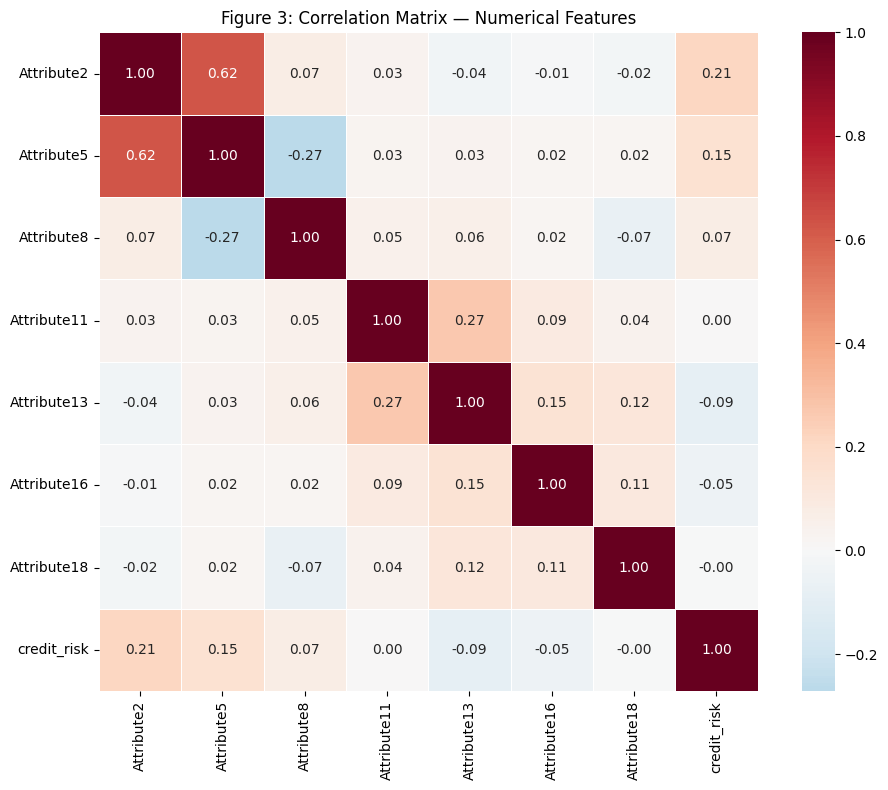

In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = num_cols + ['credit_risk']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Figure 3: Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.savefig('../shap_plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

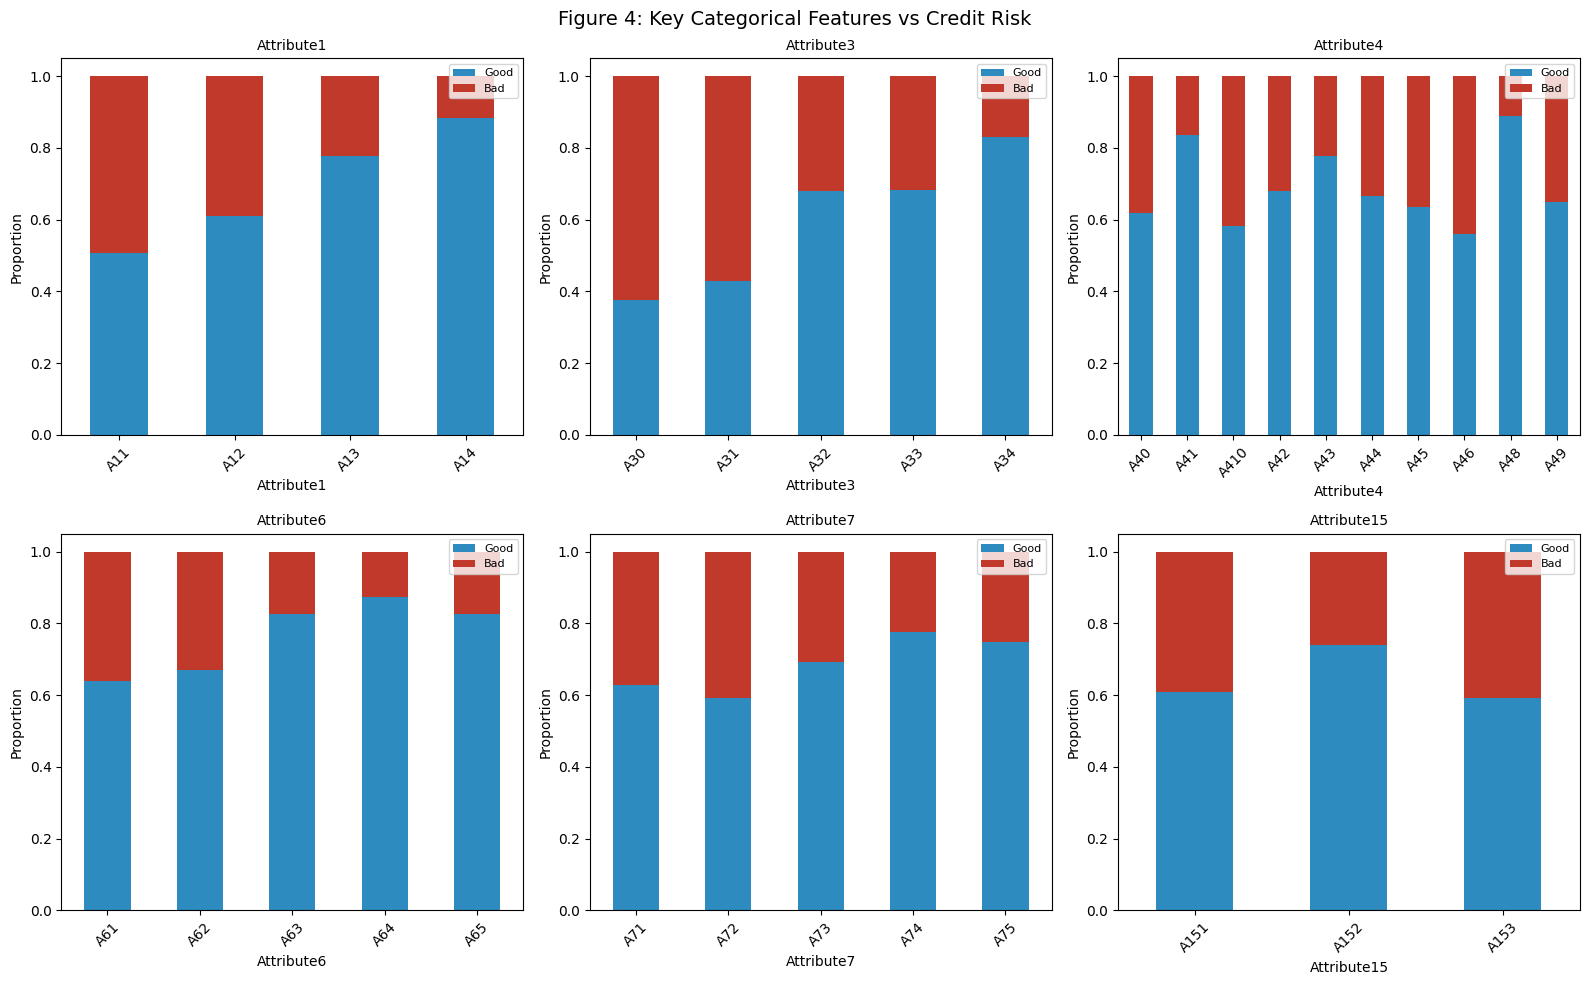

In [11]:
# Categorical features vs credit risk
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
top_cats = ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute15']

for i, col in enumerate(top_cats):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['credit_risk'], normalize='index')
    ct.plot(kind='bar', ax=ax, color=['#2E8BC0', '#C0392B'], stacked=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Proportion')
    ax.legend(['Good', 'Bad'], fontsize=8)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Figure 4: Key Categorical Features vs Credit Risk', fontsize=14)
plt.tight_layout()
plt.savefig('../shap_plots/categorical_vs_risk.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Summary statistics for the dissertation
print("=" * 60)
print("TABLE 1: Dataset Summary — UCI German Credit")
print("=" * 60)
print(f"Total records:         {len(df)}")
print(f"Total features:        {len(df.columns) - 1}")
print(f"Categorical features:  {len(cat_cols)}")
print(f"Numerical features:    {len(num_cols)}")
print(f"Missing values:        {df.isnull().sum().sum()}")
print(f"Good credit (class 0): {(df['credit_risk']==0).sum()} ({(df['credit_risk']==0).mean():.1%})")
print(f"Bad credit (class 1):  {(df['credit_risk']==1).sum()} ({(df['credit_risk']==1).mean():.1%})")
print(f"Class imbalance ratio: {(df['credit_risk']==0).sum()/(df['credit_risk']==1).sum():.1f}:1")
print(f"Cost matrix:           Misclass bad→good costs 5x more")
print(f"\nNumerical feature statistics:")
print(df[num_cols].describe().round(2))

TABLE 1: Dataset Summary — UCI German Credit
Total records:         1000
Total features:        20
Categorical features:  13
Numerical features:    7
Missing values:        0
Good credit (class 0): 700 (70.0%)
Bad credit (class 1):  300 (30.0%)
Class imbalance ratio: 2.3:1
Cost matrix:           Misclass bad→good costs 5x more

Numerical feature statistics:
       Attribute2  Attribute5  Attribute8  Attribute11  Attribute13  \
count     1000.00     1000.00     1000.00      1000.00      1000.00   
mean        20.90     3271.26        2.97         2.84        35.55   
std         12.06     2822.74        1.12         1.10        11.38   
min          4.00      250.00        1.00         1.00        19.00   
25%         12.00     1365.50        2.00         2.00        27.00   
50%         18.00     2319.50        3.00         3.00        33.00   
75%         24.00     3972.25        4.00         4.00        42.00   
max         72.00    18424.00        4.00         4.00        75.00   

